# WIS ST63268 – Wave Statistics 2014–2022
**Station:** ST63268 (North Core Banks, NC, ~20 m depth)  
**Period:** 2014–2022 (hourly WIS hindcast, monthly NetCDF)  
**Variables:** Significant wave height $H_s$, wave power $P$, and 2% runup $R_{2\%}$  
**Aggregations:** daily · seasonal · annual  
**Statistics:** max · median · 95th percentile · cumulative power

### Key equations

**Wave power** (deep-water energy flux per unit crest width):  
$$P = \frac{\rho g^2}{64\pi} H_s^2 T_e \quad [\text{W/m}], \qquad T_e = T_p / 1.05$$

**Stockdon et al. (2006) 2% runup:**  
$$R_{2\%} = 1.1 \left( 0.35\,\beta_f \sqrt{H_s L_0} + \frac{\sqrt{H_s L_0 (0.563\,\beta_f^2 + 0.004)}}{2} \right)$$
where $L_0 = g T_p^2 / (2\pi)$ and $\beta_f = 0.05$ (beach slope).

> Stockdon, H.F., Holman, R.A., Howd, P.A., Sallenger, A.H., 2006.  
> *Empirical parameterization of setup, swash, and runup.*  
> Coastal Engineering, 53(7), 573–588. https://doi.org/10.1016/j.coastaleng.2005.12.005

**Season definition:** DJF = Dec–Jan–Feb · MAM = Mar–Apr–May · JJA = Jun–Jul–Aug · SON = Sep–Oct–Nov

## 1 · Imports & configuration

In [1]:
import os, glob
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ────────────────────────────────────────────────────────────
STATION_ID  = '63268'
CACHE_DIR   = './wis_cache'
FIRST_YEAR  = 2014
LAST_YEAR   = 2022

# Physical constants
RHO  = 1025.0   # seawater density [kg/m³]
G    = 9.81     # gravitational acceleration [m/s²]
BETA = 0.05     # beach slope (Stockdon)

# Season map (meteorological seasons, DJF assigned to year of Jan/Feb)
SEASON_MAP = {12:'DJF', 1:'DJF', 2:'DJF',
               3:'MAM', 4:'MAM', 5:'MAM',
               6:'JJA', 7:'JJA', 8:'JJA',
               9:'SON',10:'SON',11:'SON'}
SEASON_ORDER = ['DJF','MAM','JJA','SON']

print(f'Station ST{STATION_ID}  |  {FIRST_YEAR}–{LAST_YEAR}')

Station ST63268  |  2014–2022


## 2 · Load cached NetCDF files → hourly DataFrame

In [2]:
records = []
for yr in range(FIRST_YEAR, LAST_YEAR + 1):
    for mo in range(1, 13):
        fpath = os.path.join(CACHE_DIR,
                    f'WIS-ocean_waves_ST{STATION_ID}_{yr}{mo:02d}.nc')
        if not os.path.exists(fpath):
            continue
        with nc.Dataset(fpath) as ds:
            time_var = ds.variables['time']
            times = nc.num2date(time_var[:], time_var.units,
                                calendar=getattr(time_var,'calendar','standard'))
            hs = ds.variables['waveHs'][:].filled(np.nan)
            tp = ds.variables['waveTp'][:].filled(np.nan)
        dts = pd.to_datetime([t.isoformat() for t in times])
        records.append(pd.DataFrame({'Hs': hs, 'Tp': tp}, index=dts))

df = pd.concat(records).sort_index()
df = df[(df.index.year >= FIRST_YEAR) & (df.index.year <= LAST_YEAR)]

print(f'Loaded {len(df):,} hourly records')
print(f'Record: {df.index[0].date()} → {df.index[-1].date()}')
print(f'Missing Hs: {df.Hs.isna().sum()}')

Loaded 78,887 hourly records
Record: 2014-01-01 → 2022-12-31
Missing Hs: 0


## 3 · Compute wave power and Stockdon runup

In [3]:
# Wave power [W/m], Te = Tp/1.05
Te = df['Tp'] / 1.05
df['P'] = (RHO * G**2) / (64 * np.pi) * df['Hs']**2 * Te          # W/m
df['P_kW'] = df['P'] / 1e3                                          # kW/m

# Stockdon et al. (2006) 2% exceedance runup
L0 = G * df['Tp']**2 / (2 * np.pi)                                  # deep-water wavelength [m]
HsL0 = df['Hs'] * L0
setup   = 0.35 * BETA * np.sqrt(HsL0)
swash   = np.sqrt(HsL0 * (0.563 * BETA**2 + 0.004)) / 2
df['R2'] = 1.1 * (setup + swash)                                     # runup [m]

# Season & season-year labels
df['season'] = df.index.month.map(SEASON_MAP)
# Season-year: DJF of Dec belongs to next year
df['sea_year'] = df.index.year
df.loc[(df.index.month == 12), 'sea_year'] += 1

df[['Hs','Tp','P_kW','R2']].describe().round(3)

,Hs,Tp,P_kW,R2
count,78887.000,78887.000,78887.000,78887.000
mean,1.282,7.523,7.563,0.625
std,0.612,2.154,12.237,0.257
min,0.172,2.648,0.074,0.124
25%,0.859,6.000,2.348,0.451
50%,1.156,7.328,4.367,0.578
75%,1.562,8.766,8.352,0.737
max,8.523,18.828,455.867,3.104


## 4 · Aggregation helper

In [4]:
def wave_stats(grp, col, dt_hours=1.0):
    """Return max, median, p95, and (for P_kW) cumulative MWh/m."""
    s = grp[col]
    out = pd.Series({
        'max'   : s.max(),
        'median': s.median(),
        'p95'   : s.quantile(0.95),
    })
    if col == 'P_kW':
        # cumulative energy: kW/m * hours → kWh/m → /1000 → MWh/m
        out['cum_MWh_m'] = s.sum() * dt_hours / 1e3
    return out

## 5 · Daily statistics

In [5]:
daily = {}
for col in ['Hs','P_kW','R2']:
    daily[col] = df.groupby(df.index.date).apply(wave_stats, col=col)
    daily[col].index = pd.to_datetime(daily[col].index)

# Flatten to single DataFrame with MultiIndex columns
daily_df = pd.concat(daily, axis=1)
daily_df.columns = ['_'.join(c) for c in daily_df.columns]
print(f'Daily stats: {len(daily_df)} days')
daily_df.head()

Daily stats: 3287 days


,Hs_max,Hs_median,Hs_p95,P_kW_max,P_kW_median,P_kW_p95,P_kW_cum_MWh_m,R2_max,R2_median,R2_p95
2014-01-01,0.906250,0.585938,0.879687,2.713249,1.298360,2.468408,0.035421,0.551191,0.456798,0.538292
2014-01-02,0.656250,0.550781,0.617188,1.689973,1.200429,1.510069,0.030349,0.507473,0.468797,0.497174
2014-01-03,2.273438,2.011719,2.264453,20.217631,15.205287,20.042788,0.322187,0.949455,0.891684,0.947853
2014-01-04,1.773438,1.183594,1.685937,12.777906,6.971838,11.615158,0.179632,0.898317,0.842181,0.896266
2014-01-05,1.804688,1.167969,1.780078,9.404014,6.850834,9.029712,0.165493,0.904811,0.871533,0.902168


## 6 · Seasonal statistics

In [6]:
seas_stats = {}
for col in ['Hs','P_kW','R2']:
    seas_stats[col] = (df.groupby(['sea_year','season'])
                         .apply(wave_stats, col=col)
                         .reset_index())

# Build clean seasonal table (pivot: sea_year × season for each stat)
def seas_pivot(col, stat):
    t = seas_stats[col][['sea_year','season', stat]].copy()
    t = t[t['sea_year'].between(FIRST_YEAR, LAST_YEAR)]
    return t.pivot(index='sea_year', columns='season', values=stat)[SEASON_ORDER]

# Print summary for each variable
for col, unit in [('Hs','m'),('P_kW','kW/m'),('R2','m')]:
    stats_list = ['max','median','p95'] + (['cum_MWh_m'] if col=='P_kW' else [])
    frames = {s: seas_pivot(col, s) for s in stats_list}
    print(f'\n── {col} [{unit}] – seasonal stats ──')
    for s, tbl in frames.items():
        print(f'  {s}:')
        print(tbl.round(2).to_string())


── Hs [m] – seasonal stats ──
  max:
season     DJF   MAM   JJA   SON
sea_year                        
2014      3.59  4.30  7.52  3.11
2015      3.88  2.75  2.41  3.77
2016      4.34  3.23  2.70  5.40
2017      2.95  4.32  2.60  4.94
2018      3.47  4.41  2.93  8.05
2019      4.34  4.11  2.55  8.52
2020      5.03  4.55  4.80  3.66
2021      4.90  3.49  3.52  4.55
2022      4.45  4.03  2.35  4.67
  median:
season     DJF   MAM   JJA   SON
sea_year                        
2014      1.38  1.21  0.99  1.00
2015      1.09  1.15  0.96  1.20
2016      1.32  1.14  0.93  1.13
2017      1.30  1.21  0.98  1.36
2018      1.39  1.41  1.07  1.24
2019      1.16  1.11  0.93  1.24
2020      1.51  1.34  0.95  1.29
2021      1.28  1.16  1.06  1.05
2022      1.23  1.25  1.02  1.16
  p95:
season     DJF   MAM   JJA   SON
sea_year                        
2014      2.73  2.57  2.05  2.10
2015      2.42  2.10  1.56  2.81
2016      2.74  2.23  1.69  2.12
2017      2.22  2.66  1.90  2.89
2018      2.44  2.88 

## 7 · Annual statistics

In [7]:
ann_stats = {}
for col in ['Hs','P_kW','R2']:
    ann_stats[col] = df.groupby(df.index.year).apply(wave_stats, col=col)
    ann_stats[col].index.name = 'Year'

# Build a single printable summary table
annual_tbl = pd.DataFrame({
    'Hs_max'       : ann_stats['Hs']['max'],
    'Hs_med'       : ann_stats['Hs']['median'],
    'Hs_p95'       : ann_stats['Hs']['p95'],
    'P_max_kW'     : ann_stats['P_kW']['max'],
    'P_med_kW'     : ann_stats['P_kW']['median'],
    'P_p95_kW'     : ann_stats['P_kW']['p95'],
    'P_cum_MWh_m'  : ann_stats['P_kW']['cum_MWh_m'],
    'R2_max_m'     : ann_stats['R2']['max'],
    'R2_med_m'     : ann_stats['R2']['median'],
    'R2_p95_m'     : ann_stats['R2']['p95'],
})

# Add long-term mean row
annual_tbl.loc['Mean'] = annual_tbl.mean()
annual_tbl.round(2)

,Hs_max,Hs_med,Hs_p95,P_max_kW,P_med_kW,P_p95_kW,P_cum_MWh_m,R2_max_m,R2_med_m,R2_p95_m
Year,,,,,,,,,,
2014,7.52,1.09,2.37,310.52,3.96,21.84,61.89,2.41,0.58,1.07
2015,3.88,1.11,2.27,66.58,4.15,20.08,57.74,1.63,0.57,1.03
2016,5.40,1.12,2.29,144.89,4.12,20.97,60.85,1.84,0.57,1.09
2017,4.94,1.17,2.48,163.92,4.62,24.15,68.75,2.39,0.59,1.10
2018,8.05,1.25,2.66,427.00,5.12,31.77,87.51,3.10,0.60,1.18
2019,8.52,1.11,2.39,455.87,3.90,22.56,62.03,2.92,0.55,1.04
2020,5.03,1.21,2.59,125.76,4.84,27.82,74.37,2.28,0.59,1.18
2021,4.55,1.14,2.17,114.26,4.35,17.43,55.95,1.89,0.58,0.99
2022,4.67,1.18,2.45,104.66,4.45,25.89,67.55,2.06,0.57,1.19


## 8 · Plots

### 8a · Daily time series (Hs, P, R2)

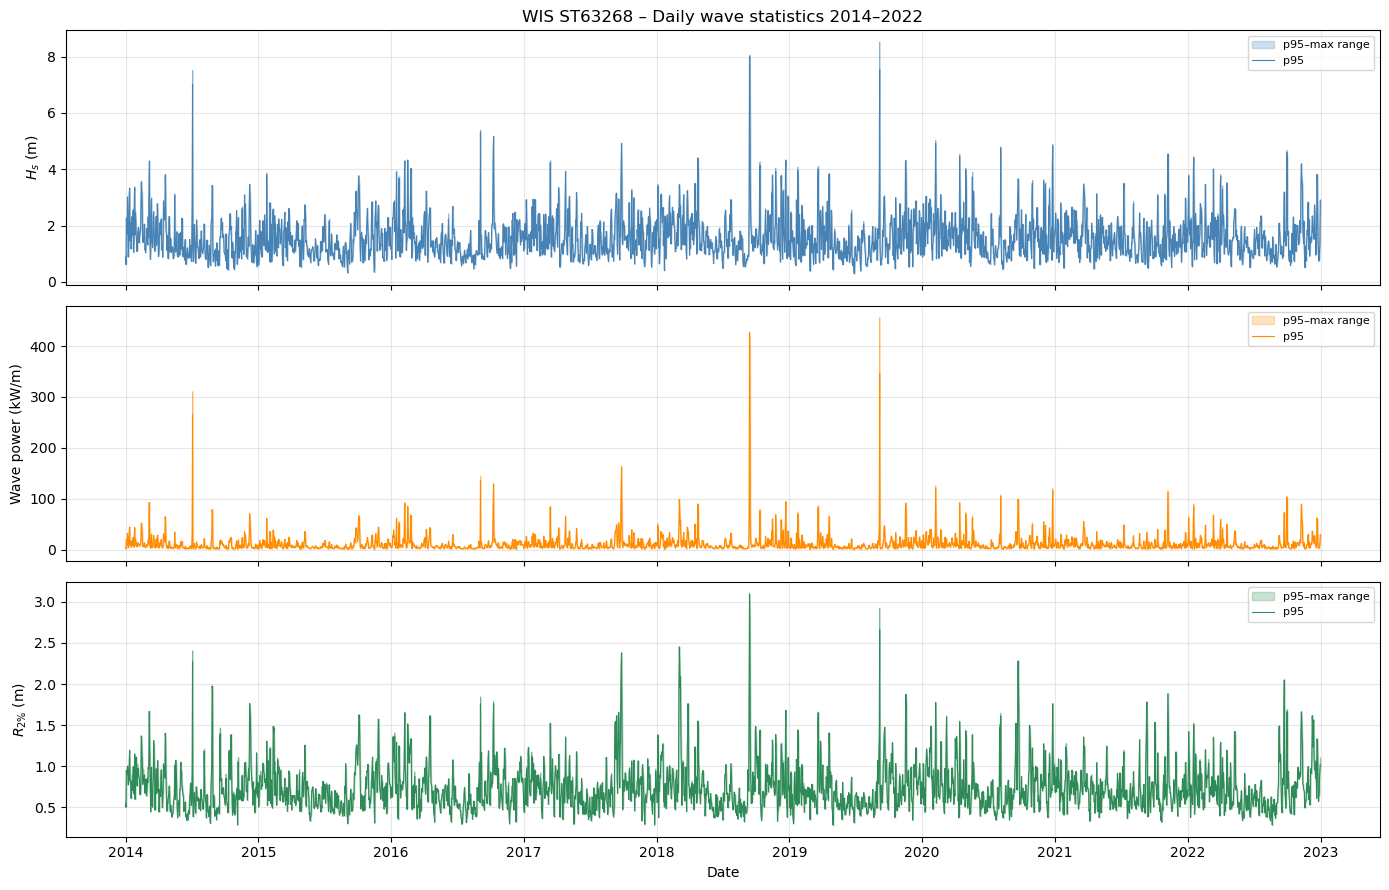

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

pairs = [
    ('Hs_max',    'Hs_p95',    '$H_s$ (m)',       'steelblue'),
    ('P_kW_max',  'P_kW_p95',  'Wave power (kW/m)','darkorange'),
    ('R2_max',    'R2_p95',    '$R_{2\\%}$ (m)',   'seagreen'),
]

for ax, (col_max, col_p95, ylabel, color) in zip(axes, pairs):
    ax.fill_between(daily_df.index, daily_df[col_p95], daily_df[col_max],
                    alpha=0.25, color=color, label='p95–max range')
    ax.plot(daily_df.index, daily_df[col_p95], lw=0.8, color=color, label='p95')
    ax.plot(daily_df.index, daily_df[col_max], lw=0.5, color=color, alpha=0.5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'WIS ST{STATION_ID} – Daily wave statistics 2014–2022', fontsize=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('ST63268_daily_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### 8b · Seasonal box plots

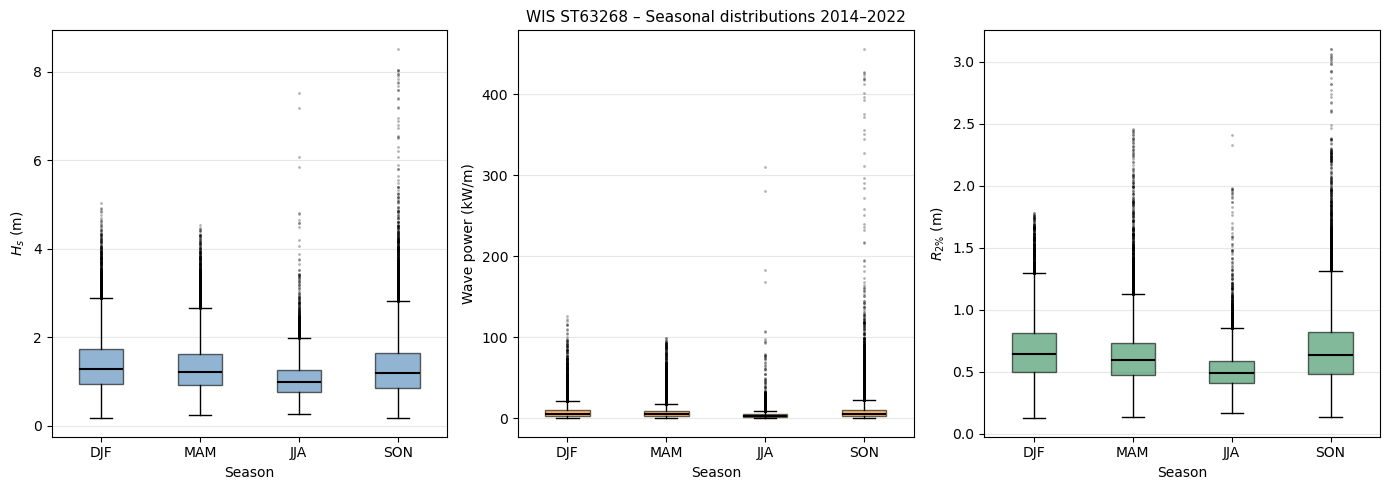

In [9]:
# Assign season to hourly data for box plots
df['season_cat'] = pd.Categorical(df['season'], categories=SEASON_ORDER, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_vars = [('Hs','$H_s$ (m)','steelblue'),
             ('P_kW','Wave power (kW/m)','darkorange'),
             ('R2','$R_{2\\%}$ (m)','seagreen')]

for ax, (col, ylabel, color) in zip(axes, plot_vars):
    groups = [df.loc[df['season']==s, col].dropna().values for s in SEASON_ORDER]
    bp = ax.boxplot(groups, labels=SEASON_ORDER, patch_artist=True,
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=1), flierprops=dict(marker='.', ms=2, alpha=0.3))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Season')
    ax.grid(True, axis='y', alpha=0.3)

axes[1].set_title(f'WIS ST{STATION_ID} – Seasonal distributions 2014–2022', fontsize=11)
plt.tight_layout()
plt.savefig('ST63268_seasonal_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 8c · Annual bar charts with 95th percentile and cumulative power

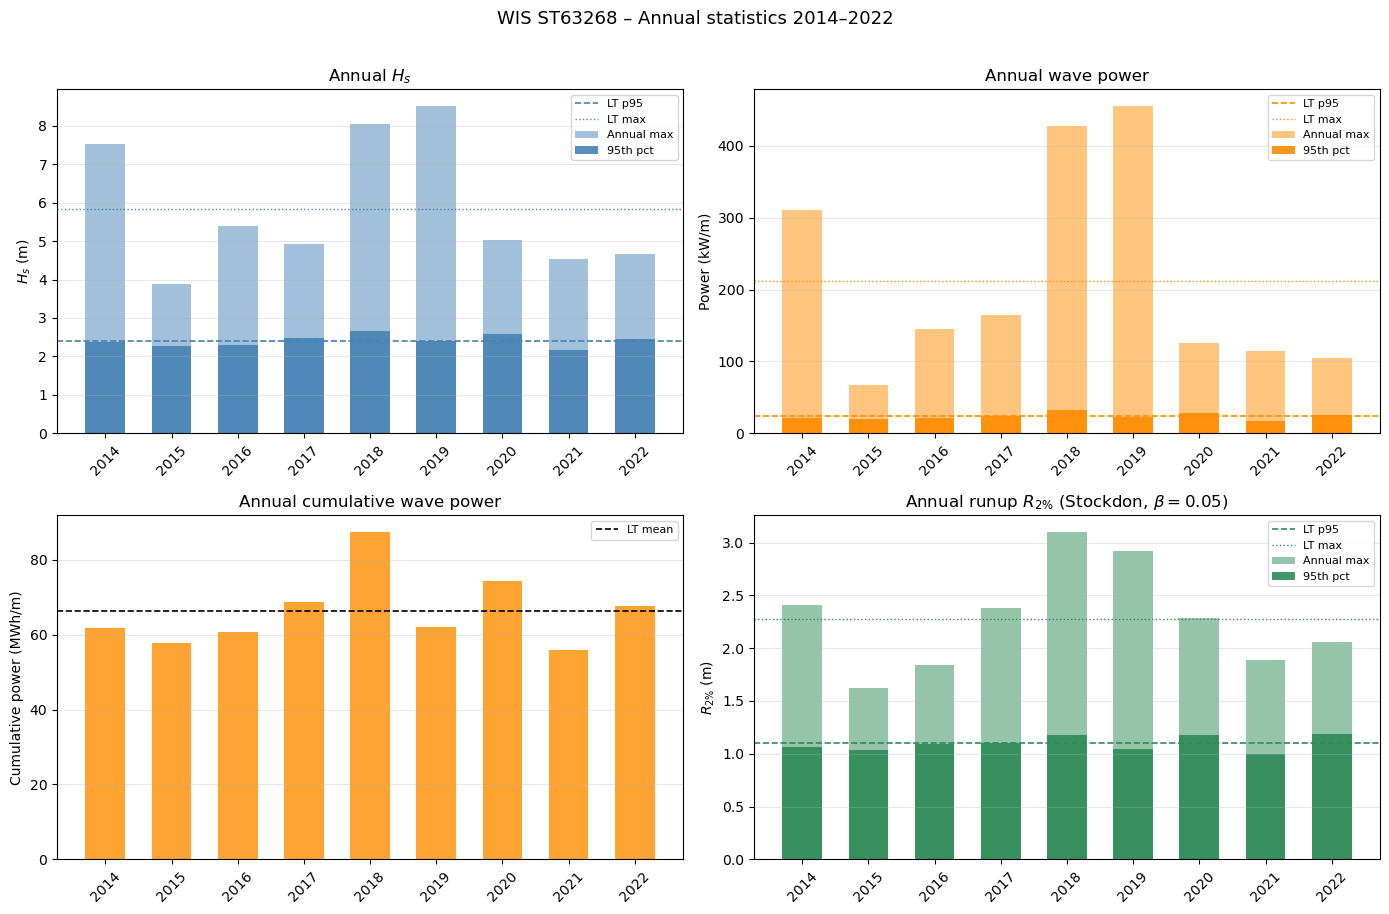

In [10]:
years = annual_tbl.index[annual_tbl.index != 'Mean'].astype(int)
ann = annual_tbl.loc[years]
lt = annual_tbl.loc['Mean']
x = np.arange(len(years))
w = 0.6

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Hs: max and p95 ──
ax = axes[0,0]
ax.bar(x, ann['Hs_max'], w, label='Annual max', color='steelblue', alpha=0.5)
ax.bar(x, ann['Hs_p95'], w, label='95th pct',   color='steelblue', alpha=0.9)
ax.axhline(lt['Hs_p95'],  ls='--', color='steelblue', lw=1.2, label='LT p95')
ax.axhline(lt['Hs_max'],  ls=':',  color='steelblue', lw=1.0, label='LT max')
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('$H_s$ (m)'); ax.set_title('Annual $H_s$')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

# ── P: max and p95 ──
ax = axes[0,1]
ax.bar(x, ann['P_max_kW'], w, label='Annual max', color='darkorange', alpha=0.5)
ax.bar(x, ann['P_p95_kW'], w, label='95th pct',   color='darkorange', alpha=0.9)
ax.axhline(lt['P_p95_kW'], ls='--', color='darkorange', lw=1.2, label='LT p95')
ax.axhline(lt['P_max_kW'], ls=':',  color='darkorange', lw=1.0, label='LT max')
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('Power (kW/m)'); ax.set_title('Annual wave power')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

# ── Cumulative annual power ──
ax = axes[1,0]
ax.bar(x, ann['P_cum_MWh_m'], w, color='darkorange', alpha=0.8)
ax.axhline(lt['P_cum_MWh_m'], ls='--', color='k', lw=1.2, label='LT mean')
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('Cumulative power (MWh/m)'); ax.set_title('Annual cumulative wave power')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

# ── R2: max and p95 ──
ax = axes[1,1]
ax.bar(x, ann['R2_max_m'], w, label='Annual max', color='seagreen', alpha=0.5)
ax.bar(x, ann['R2_p95_m'], w, label='95th pct',   color='seagreen', alpha=0.9)
ax.axhline(lt['R2_p95_m'], ls='--', color='seagreen', lw=1.2, label='LT p95')
ax.axhline(lt['R2_max_m'], ls=':',  color='seagreen', lw=1.0, label='LT max')
ax.set_xticks(x); ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('$R_{2\\%}$ (m)'); ax.set_title('Annual runup $R_{2\\%}$ (Stockdon, $\\beta=0.05$)')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

fig.suptitle(f'WIS ST{STATION_ID} – Annual statistics 2014–2022', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('ST63268_annual_stats.png', dpi=150, bbox_inches='tight')
plt.show()

### 8d · Seasonal heatmaps (year × season)

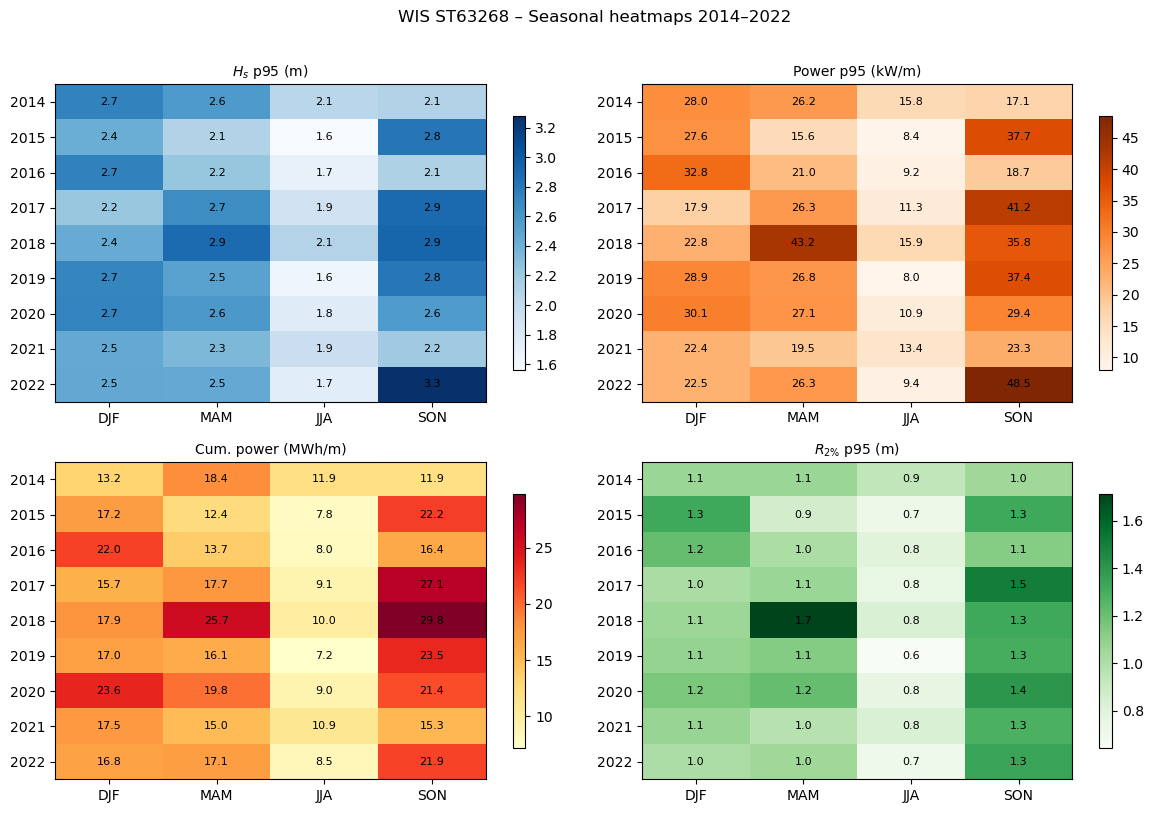

In [11]:
import matplotlib.colors as mcolors

# Build seasonal pivot tables for p95 of each variable
def seas_pivot_stat(col, stat):
    s = seas_stats[col]
    s = s[s['sea_year'].between(FIRST_YEAR, LAST_YEAR)]
    return s.pivot(index='sea_year', columns='season', values=stat)[SEASON_ORDER]

heat_vars = [
    ('Hs',   'p95', '$H_s$ p95 (m)',            'Blues'),
    ('P_kW', 'p95', 'Power p95 (kW/m)',          'Oranges'),
    ('P_kW', 'cum_MWh_m', 'Cum. power (MWh/m)', 'YlOrRd'),
    ('R2',   'p95', '$R_{2\\%}$ p95 (m)',         'Greens'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, stat, title, cmap) in zip(axes.flat, heat_vars):
    data = seas_pivot_stat(col, stat)
    im = ax.imshow(data.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(4)); ax.set_xticklabels(SEASON_ORDER)
    ax.set_yticks(range(len(data))); ax.set_yticklabels(data.index)
    ax.set_title(title, fontsize=10)
    # annotate cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                        fontsize=8, color='k')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(f'WIS ST{STATION_ID} – Seasonal heatmaps 2014–2022', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('ST63268_seasonal_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Summary tables

In [12]:
# ── Annual summary table ──────────────────────────────────────────────────────
print('=== ANNUAL STATISTICS (2014–2022) ===')
print(annual_tbl.round(2).to_string())

=== ANNUAL STATISTICS (2014–2022) ===
      Hs_max  Hs_med  Hs_p95  P_max_kW  P_med_kW  P_p95_kW  P_cum_MWh_m  R2_max_m  R2_med_m  R2_p95_m
Year                                                                                                 
2014    7.52    1.09    2.37    310.52      3.96     21.84        61.89      2.41      0.58      1.07
2015    3.88    1.11    2.27     66.58      4.15     20.08        57.74      1.63      0.57      1.03
2016    5.40    1.12    2.29    144.89      4.12     20.97        60.85      1.84      0.57      1.09
2017    4.94    1.17    2.48    163.92      4.62     24.15        68.75      2.39      0.59      1.10
2018    8.05    1.25    2.66    427.00      5.12     31.77        87.51      3.10      0.60      1.18
2019    8.52    1.11    2.39    455.87      3.90     22.56        62.03      2.92      0.55      1.04
2020    5.03    1.21    2.59    125.76      4.84     27.82        74.37      2.28      0.59      1.18
2021    4.55    1.14    2.17    114.26      

In [13]:
# ── Seasonal summary (all-year mean by season) ────────────────────────────────
print('=== SEASONAL CLIMATOLOGY (2014–2022 mean by season) ===')
for col, unit in [('Hs','m'), ('P_kW','kW/m'), ('R2','m')]:
    stats_list = ['max','median','p95'] + (['cum_MWh_m'] if col=='P_kW' else [])
    rows = {}
    for stat in stats_list:
        rows[stat] = seas_pivot_stat(col, stat).mean()
    tbl = pd.DataFrame(rows).T
    tbl.index.name = 'stat'
    print(f'\n{col} [{unit}]:')
    print(tbl.round(2).to_string())

=== SEASONAL CLIMATOLOGY (2014–2022 mean by season) ===

Hs [m]:
season   DJF   MAM   JJA   SON
stat                          
max     4.11  3.91  3.49  5.19
median  1.30  1.22  0.99  1.18
p95     2.55  2.48  1.82  2.63

P_kW [kW/m]:
season       DJF    MAM    JJA     SON
stat                                  
max        80.99  73.53  67.90  179.08
median      5.74   4.97   2.97    5.06
p95        25.89  25.76  11.37   32.12
cum_MWh_m  17.88  17.33   9.15   21.06

R2 [m]:
season   DJF   MAM   JJA   SON
stat                          
max     1.57  1.62  1.27  2.17
median  0.64  0.59  0.49  0.63
p95     1.11  1.12  0.77  1.29


---
### Data source & methods

| Item | Detail |
|---|---|
| **Data** | USACE ERDC Wave Information Studies (WIS) hindcast |
| **Station** | ST63268 – North Core Banks, NC (~20 m depth) |
| **Period** | 2014–2022, hourly resolution |
| **Wave model** | NOAA WAVEWATCH III, CFSR/CFSv2 wind forcing |
| **Power** | $P = \\frac{\\rho g^2}{64\\pi} H_s^2 T_e$, $T_e = T_p/1.05$ (JONSWAP) |
| **Runup** | Stockdon et al. (2006), $\\beta_f = 0.05$ |
| **Cumulative power** | $\\sum P \\cdot \\Delta t$ (hourly), converted to MWh/m |
| **Seasons** | DJF / MAM / JJA / SON (meteorological; Dec → next year) |

**Reference:**  
Stockdon, H.F., Holman, R.A., Howd, P.A., Sallenger, A.H., 2006. Empirical parameterization of setup, swash, and runup. *Coastal Engineering*, 53(7), 573–588. https://doi.org/10.1016/j.coastaleng.2005.12.005